# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import time 

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb


from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split


df = pd.read_csv('taxi.csv', parse_dates=['datetime'], index_col='datetime').sort_index()


print('Los datos de la serie de tiempo son cronologicos?:')
print(df.index.is_monotonic_increasing)
df = df.resample('1h').sum()
print('-' * 45)
print(df.info())
print('-' * 45)
print(df.head())
print('-' * 45)
print(df.describe())
print('-' * 45)
print('NA values')
print(df.isna().sum())

Los datos de la serie de tiempo son cronologicos?:
True
---------------------------------------------
<class 'pandas.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None
---------------------------------------------
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43
---------------------------------------------
        num_orders
count  4416.000000
mean     84.422781
std      45.023853
min       0.000000
25%      54.000000
50%      78.000000
75%     107.000000
max     462.000000
---------------------------------------------
NA values
num_orders    0
dtype: int64


## Análisis

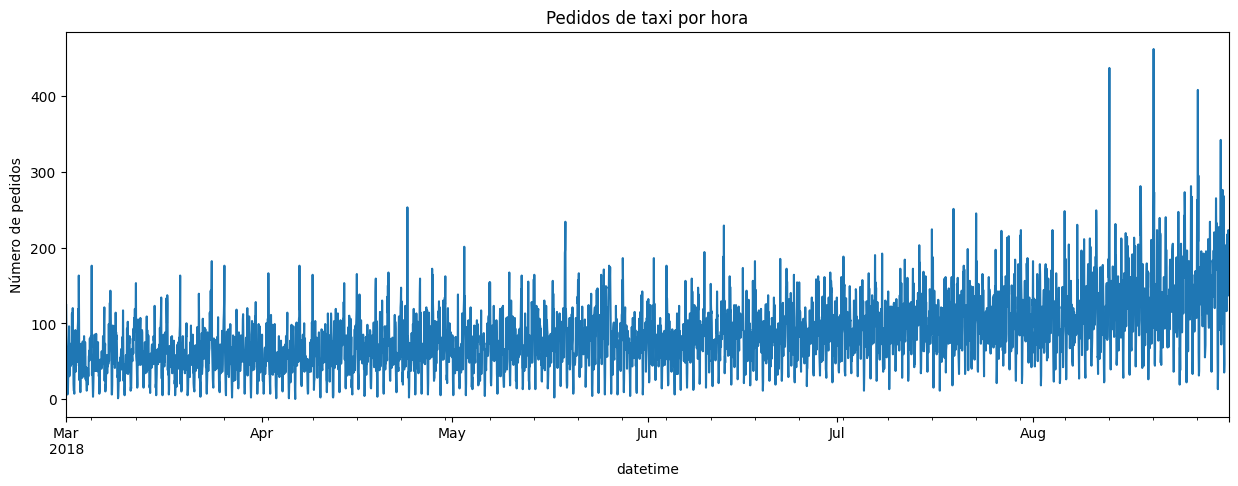

<Figure size 1500x500 with 0 Axes>

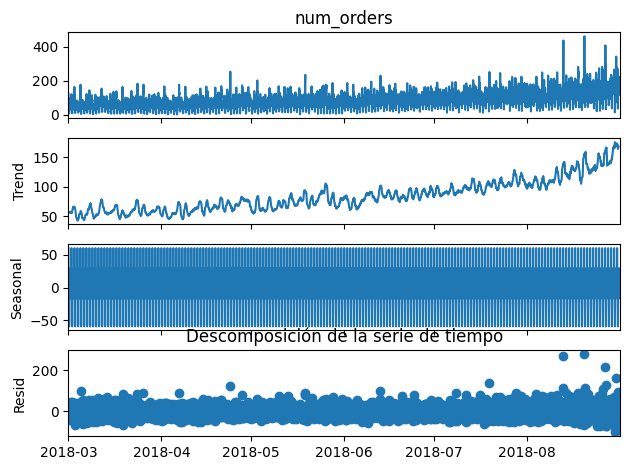

In [2]:
#hagamos una grafica de la serie de tiempo para tener una vista previa de la serie de tiempo
plt.figure(figsize=(15, 5))
df['num_orders'].plot()
plt.title('Pedidos de taxi por hora')
plt.ylabel('Número de pedidos')
plt.show()

#descomponemos la serie de tiempo para ver sus componentes
descomposed = seasonal_decompose(df['num_orders'])
plt.figure(figsize=(15, 5))
descomposed.plot()
plt.title('Descomposición de la serie de tiempo')
plt.show()

## Formación

In [3]:
#creamos las caracteristicas para el modelo de prediccion, en este caso vamos a usar la tendencia y la estacionalidad como caracteristicas
def make_features(data, max_lag, rolling_mean_size):
    data = data.copy()
    data['hour'] = data.index.hour
    data['day_of_week  '] = data.index.dayofweek
    data['is_weekend'] = data.index.dayofweek.isin([5, 6]).astype(int)
    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()
    data['rolling_std'] = data['num_orders'].shift().rolling(rolling_mean_size).std()
    
    return data

df_features = make_features(df, 4, 4)

#si hay valores nulos, los eliminamos
df_features = df_features.dropna()

#Validamos que no hay valores nulos en las caracteristicas creadas
print('Valores nulos en las caracteristicas creadas:')
print(df_features.isna().sum())
print('-' * 45)


#validamos los datos de las caracteristicas creadas
print('Datos de las caracteristicas creadas:')
print(df_features.head(10))
print('-' * 45)

#Separamos los datos en entrenamiento y prueba, para poder evaluar el modelo
train, test = train_test_split(df_features, test_size=0.2, shuffle=False) 

print('Train shape:', train.shape)
print('-' * 45)
print('Test shape:', test.shape)

#Separamos las caracteristicas y la variable objetivo
X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']
X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']


#comprobampos que los datos de entrenamiento y prueba son cronologicos
print('Los datos de entrenamiento son cronologicos?:') 
print(train.index.max() < test.index.min())
print(train.index.max())
print(test.index.min())

Valores nulos en las caracteristicas creadas:
num_orders       0
hour             0
day_of_week      0
is_weekend       0
lag_1            0
lag_2            0
lag_3            0
lag_4            0
rolling_mean     0
rolling_std      0
dtype: int64
---------------------------------------------
Datos de las caracteristicas creadas:
                     num_orders  hour  day_of_week    is_weekend  lag_1  \
datetime                                                                  
2018-03-01 04:00:00          43     4              3           0   66.0   
2018-03-01 05:00:00           6     5              3           0   43.0   
2018-03-01 06:00:00          12     6              3           0    6.0   
2018-03-01 07:00:00          15     7              3           0   12.0   
2018-03-01 08:00:00          34     8              3           0   15.0   
2018-03-01 09:00:00          69     9              3           0   34.0   
2018-03-01 10:00:00          64    10              3           0   

## Prueba

In [4]:
def mse_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)
#funcion para evaluar el modelo y guardar los resultados en un diccionario
results = []
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    
    pred = model.predict(X_te)
    rmse = mse_manual(y_te, pred)**0.5
    
    results.append({
        'Modelo': name,
        'RMSE': round(rmse, 2),
        'Tiempo Entrenamiento (s)': round(train_time, 2)
    })
    
    print(f"{name:25} → RMSE: {rmse:.2f} | Tiempo: {train_time:.2f}s")

# Modelos
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.1, max_depth=10, random_state=42, verbose=-1)
}

for name, model in models.items():
    evaluate_model(name, model, X_train, y_train, X_test, y_test)

# Mostrar resultados
results_df = pd.DataFrame(results)
print("\n=== RESULTADOS ===")
print(results_df.sort_values('RMSE'))

Linear Regression         → RMSE: 51.86 | Tiempo: 0.00s
Random Forest             → RMSE: 49.50 | Tiempo: 0.29s
LightGBM                  → RMSE: 47.23 | Tiempo: 1.63s

=== RESULTADOS ===
              Modelo   RMSE  Tiempo Entrenamiento (s)
2           LightGBM  47.23                      1.63
1      Random Forest  49.50                      0.29
0  Linear Regression  51.86                      0.00


El modelo que mejor se ajusta a la metrica es LightGBM

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [X]  El código no tiene errores
- [X]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [X]  	
Los datos han sido descargados y preparados.
- [X]  Se ha realizado el paso 2: los datos han sido analizados
- [X]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [X]  Se han evaluado los modelos. Se expuso una conclusión
- [X] La *RECM* para el conjunto de prueba no es más de 48